# NOAA Storm Events — Consolidación y EDA

Este notebook consolida los archivos CSV del *Storm Events Database* de NOAA distribuidos en múltiples carpetas (cada una con ~20 años de eventos) y ejecuta un análisis exploratorio inicial.

**Supuestos:**
- Los archivos conservan el formato y los nombres originales de NOAA (`StormEvents_details-*.csv`, `StormEvents_locations-*.csv`, `StormEvents_fatalities-*.csv`), aunque estén descomprimidos.
- Las tres categorías se vinculan mediante `EVENT_ID`.

## 1. Configuración

In [2]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 60)
sns.set_theme(style='whitegrid', context='notebook')

# Listar aquí todas las carpetas que contienen los CSV (una por bloque de ~20 años)
DATA_DIRS = [
    Path('./datasets/StormEvents_1970'),
    Path('./datasets/StormEvents_1971-1990'),
    Path('./datasets/StormEvents_1991-2010'),
    Path('./datasets/StormEvents_2011-2026'),
]

## 2. Carga y consolidación

Se recorren todas las carpetas y se clasifican los archivos por prefijo. Cada tipo se concatena en un único DataFrame.

In [3]:
FILE_PATTERNS = {
    'details':    re.compile(r'StormEvents_details-.*\.csv$',    re.IGNORECASE),
    'locations':  re.compile(r'StormEvents_locations-.*\.csv$',  re.IGNORECASE),
    'fatalities': re.compile(r'StormEvents_fatalities-.*\.csv$', re.IGNORECASE),
}

def discover_files(dirs):
    """Devuelve un dict {tipo: [paths]} con todos los CSV encontrados."""
    found = {k: [] for k in FILE_PATTERNS}
    for d in dirs:
        if not d.exists():
            print(f'[aviso] carpeta no encontrada: {d}')
            continue
        for f in d.glob('*.csv'):
            for kind, pattern in FILE_PATTERNS.items():
                if pattern.search(f.name):
                    found[kind].append(f)
                    break
    for kind, paths in found.items():
        print(f'{kind:<11}: {len(paths)} archivo(s)')
    return found

files = discover_files(DATA_DIRS)

details    : 57 archivo(s)
locations  : 57 archivo(s)
fatalities : 57 archivo(s)


In [4]:
def load_concat(paths, label):
    """Concatena una lista de CSV reportando filas por archivo."""
    frames = []
    for p in sorted(paths):
        df = pd.read_csv(p, low_memory=False)
        frames.append(df)
        print(f'  {p.name}: {len(df):,} filas')
    if not frames:
        return pd.DataFrame()
    out = pd.concat(frames, ignore_index=True)
    print(f'{label} total: {len(out):,} filas\n')
    return out

print('=== DETAILS ===')
details = load_concat(files['details'], 'details')
print('=== LOCATIONS ===')
locations = load_concat(files['locations'], 'locations')
print('=== FATALITIES ===')
fatalities = load_concat(files['fatalities'], 'fatalities')

=== DETAILS ===
  StormEvents_details-ftp_v1.0_d1970_c20260323.csv: 3,215 filas
  StormEvents_details-ftp_v1.0_d1971_c20260323.csv: 3,471 filas
  StormEvents_details-ftp_v1.0_d1972_c20260323.csv: 2,171 filas
  StormEvents_details-ftp_v1.0_d1973_c20260323.csv: 4,453 filas
  StormEvents_details-ftp_v1.0_d1974_c20260323.csv: 5,375 filas
  StormEvents_details-ftp_v1.0_d1975_c20260323.csv: 4,975 filas
  StormEvents_details-ftp_v1.0_d1976_c20260323.csv: 3,768 filas
  StormEvents_details-ftp_v1.0_d1977_c20260323.csv: 3,728 filas
  StormEvents_details-ftp_v1.0_d1978_c20260323.csv: 3,657 filas
  StormEvents_details-ftp_v1.0_d1979_c20260323.csv: 4,279 filas
  StormEvents_details-ftp_v1.0_d1980_c20260323.csv: 6,136 filas
  StormEvents_details-ftp_v1.0_d1981_c20260323.csv: 4,517 filas
  StormEvents_details-ftp_v1.0_d1982_c20260323.csv: 7,126 filas
  StormEvents_details-ftp_v1.0_d1983_c20260323.csv: 8,322 filas
  StormEvents_details-ftp_v1.0_d1984_c20260323.csv: 7,335 filas
  StormEvents_details-ft

## 3. Limpieza y enriquecimiento

- Conversión de fechas.
- Normalización de columnas de daños (`DAMAGE_PROPERTY`, `DAMAGE_CROPS`) que vienen como strings con sufijos `K`, `M`, `B`.
- Eliminación de duplicados por `EVENT_ID`.

In [5]:
def parse_damage(value):
    """Convierte montos de daño de NOAA a float.

    Distingue tres casos:
      - vacío / no reportado   -> np.nan  (FALTANTE genuino)
      - cero explícito ('0')   -> 0.0     (SIN daño)
      - valor con sufijo K/M/B -> float escalado
    """
    if pd.isna(value):
        return np.nan
    s = str(value).strip().upper().replace(',', '')
    if s in ('', 'NAN', 'NONE'):
        return np.nan          # antes devolvía 0.0 -> colapsaba faltante con cero
    if s in ('0', '0.0', '0.00', '0K', '0M', '0B'):
        return 0.0
    multipliers = {'K': 1e3, 'M': 1e6, 'B': 1e9, 'T': 1e12, 'H': 1e2}
    if s[-1] in multipliers:
        try:
            return float(s[:-1]) * multipliers[s[-1]]
        except ValueError:
            return np.nan
    try:
        return float(s)
    except ValueError:
        return np.nan

# Fechas — reconstrucción desde columnas numéricas para evitar bug del año de 2 dígitos
def build_datetime(df, prefix):
    """Reconstruye datetime desde columnas numéricas del CSV de NOAA."""
    ym  = df[f'{prefix}_YEARMONTH'].astype('Int64').astype(str)
    day = df[f'{prefix}_DAY'].astype('Int64').astype(str).str.zfill(2)
    t   = df[f'{prefix}_TIME'].astype('Int64').astype(str).str.zfill(4)
    year  = ym.str[:4]
    month = ym.str[4:6]
    return pd.to_datetime(
        year + '-' + month + '-' + day + ' ' + t.str[:2] + ':' + t.str[2:],
        format='%Y-%m-%d %H:%M', errors='coerce'
    )

details['BEGIN_DATE_TIME'] = build_datetime(details, 'BEGIN')
details['END_DATE_TIME']   = build_datetime(details, 'END')
details['YEAR']  = details['BEGIN_DATE_TIME'].dt.year
details['MONTH'] = details['BEGIN_DATE_TIME'].dt.month

# Daños — se preservan los faltantes como NaN (NO se aplastan a 0)
for col in ('DAMAGE_PROPERTY', 'DAMAGE_CROPS'):
    if col in details.columns:
        details[f'{col}_USD'] = details[col].apply(parse_damage)
        # bandera: True si el daño fue efectivamente reportado (no faltante)
        details[f'{col}_REPORTED'] = details[f'{col}_USD'].notna()

# Duplicados
before = len(details)
details = details.drop_duplicates(subset='EVENT_ID', keep='first')
print(f'Duplicados eliminados en details: {before - len(details):,}')
print(f'Eventos únicos: {len(details):,}')

# Chequeo rápido del efecto del cambio
for col in ('DAMAGE_PROPERTY_USD', 'DAMAGE_CROPS_USD'):
    n_nan = details[col].isna().sum()
    n_zero = (details[col] == 0).sum()
    print(f'{col}: faltantes={n_nan:,} ({n_nan/len(details)*100:.1f}%) | '
          f'ceros explícitos={n_zero:,} ({n_zero/len(details)*100:.1f}%)')

Duplicados eliminados en details: 0
Eventos únicos: 1,983,334
DAMAGE_PROPERTY_USD: faltantes=614,889 (31.0%) | ceros explícitos=931,571 (47.0%)
DAMAGE_CROPS_USD: faltantes=726,904 (36.7%) | ceros explícitos=1,217,583 (61.4%)


## 4. Vista general

In [6]:
# Cuántas fechas quedaron sin parsear
print('NaT en BEGIN:', details['BEGIN_DATE_TIME'].isna().sum())
print('NaT en END:  ', details['END_DATE_TIME'].isna().sum())

# Distribución de años para ver el hueco
print(details['BEGIN_DATE_TIME'].dt.year.value_counts().sort_index().head(20))
print(details['BEGIN_DATE_TIME'].dt.year.value_counts().sort_index().tail(20))

# Eventos con fechas futuras (claramente erróneas)
futuros = details[details['BEGIN_DATE_TIME'] > '2026-12-31']
print(f'\nEventos con fecha futura: {len(futuros):,}')
print(futuros[['EVENT_ID', 'YEAR', 'BEGIN_DATE_TIME']].head(10))

print('Rango temporal:',
      details['BEGIN_DATE_TIME'].min(), '→', details['BEGIN_DATE_TIME'].max())
print(f'Tipos de evento únicos: {details["EVENT_TYPE"].nunique()}')
print(f'Estados cubiertos: {details["STATE"].nunique()}')
details.head()

NaT en BEGIN: 0
NaT en END:   0
BEGIN_DATE_TIME
1970     3215
1971     3471
1972     2171
1973     4453
1974     5375
1975     4975
1976     3768
1977     3728
1978     3657
1979     4279
1980     6136
1981     4517
1982     7126
1983     8322
1984     7335
1985     7979
1986     8725
1987     7363
1988     7257
1989    10407
Name: count, dtype: int64
BEGIN_DATE_TIME
2007    59011
2008    71190
2009    57398
2010    62809
2011    79091
2012    64503
2013    59986
2014    59475
2015    57907
2016    56005
2017    57041
2018    62699
2019    67864
2020    61281
2021    61389
2022    69887
2023    75593
2024    69801
2025    72241
2026     6714
Name: count, dtype: int64

Eventos con fecha futura: 0
Empty DataFrame
Columns: [EVENT_ID, YEAR, BEGIN_DATE_TIME]
Index: []
Rango temporal: 1970-01-05 21:30:00 → 2026-01-31 23:40:00
Tipos de evento únicos: 56
Estados cubiertos: 69


,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,YEAR,MONTH_NAME,EVENT_TYPE,CZ_TYPE,CZ_FIPS,CZ_NAME,WFO,BEGIN_DATE_TIME,CZ_TIMEZONE,END_DATE_TIME,INJURIES_DIRECT,INJURIES_INDIRECT,DEATHS_DIRECT,DEATHS_INDIRECT,DAMAGE_PROPERTY,DAMAGE_CROPS,SOURCE,MAGNITUDE,MAGNITUDE_TYPE,FLOOD_CAUSE,CATEGORY,TOR_F_SCALE,TOR_LENGTH,TOR_WIDTH,TOR_OTHER_WFO,TOR_OTHER_CZ_STATE,TOR_OTHER_CZ_FIPS,TOR_OTHER_CZ_NAME,BEGIN_RANGE,BEGIN_AZIMUTH,BEGIN_LOCATION,END_RANGE,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE,DATA_SOURCE,MONTH,DAMAGE_PROPERTY_USD,DAMAGE_PROPERTY_REPORTED,DAMAGE_CROPS_USD,DAMAGE_CROPS_REPORTED
0,197009,4,1650,197009,4,1650,NaN,9981065,ARKANSAS,5.0,1970,September,Thunderstorm Wind,C,93,MISSISSIPPI,NaN,1970-09-04 16:50:00,CST,1970-09-04 16:50:00,0,0,0,0,0,0,NaN,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.70,-90.08,NaN,NaN,NaN,NaN,PUB,9,0.0,True,0.0,True
1,197010,8,1655,197010,8,1655,NaN,10058129,MISSOURI,29.0,1970,October,Tornado,C,197,SCHUYLER,NaN,1970-10-08 16:55:00,CST,1970-10-08 16:55:00,0,0,0,0,25K,0,NaN,0.0,NaN,NaN,NaN,F1,4.3,150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.42,-92.57,40.48,-92.6,NaN,NaN,PUB,10,25000.0,True,0.0,True
2,197006,4,1615,197006,4,1615,NaN,10047491,MISSISSIPPI,28.0,1970,June,Thunderstorm Wind,C,159,WINSTON,NaN,1970-06-04 16:15:00,CST,1970-06-04 16:15:00,0,0,0,0,0,0,NaN,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.00,-89.18,NaN,NaN,NaN,NaN,PUB,6,0.0,True,0.0,True
3,197006,11,2200,197006,11,2200,NaN,10056944,MISSOURI,29.0,1970,June,Thunderstorm Wind,C,9,BARRY,NaN,1970-06-11 22:00:00,CST,1970-06-11 22:00:00,0,0,0,0,0,0,NaN,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.78,-94.00,NaN,NaN,NaN,NaN,PUB,6,0.0,True,0.0,True
4,197007,1,2100,197007,1,2100,NaN,10052308,MINNESOTA,27.0,1970,July,Thunderstorm Wind,C,93,MEEKER,NaN,1970-07-01 21:00:00,CST,1970-07-01 21:00:00,0,0,0,0,0,0,NaN,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.08,-94.40,NaN,NaN,NaN,NaN,PUB,7,0.0,True,0.0,True


In [7]:
details.info()

<class 'pandas.DataFrame'>
RangeIndex: 1983334 entries, 0 to 1983333
Data columns (total 56 columns):
 #   Column                    Dtype         
---  ------                    -----         
 0   BEGIN_YEARMONTH           int64         
 1   BEGIN_DAY                 int64         
 2   BEGIN_TIME                int64         
 3   END_YEARMONTH             int64         
 4   END_DAY                   int64         
 5   END_TIME                  int64         
 6   EPISODE_ID                float64       
 7   EVENT_ID                  int64         
 8   STATE                     str           
 9   STATE_FIPS                float64       
 10  YEAR                      int32         
 11  MONTH_NAME                str           
 12  EVENT_TYPE                str           
 13  CZ_TYPE                   str           
 14  CZ_FIPS                   int64         
 15  CZ_NAME                   str           
 16  WFO                       object        
 17  BEGIN_DATE_TIME    

## 5. EDA

### 5.1 Eventos por año

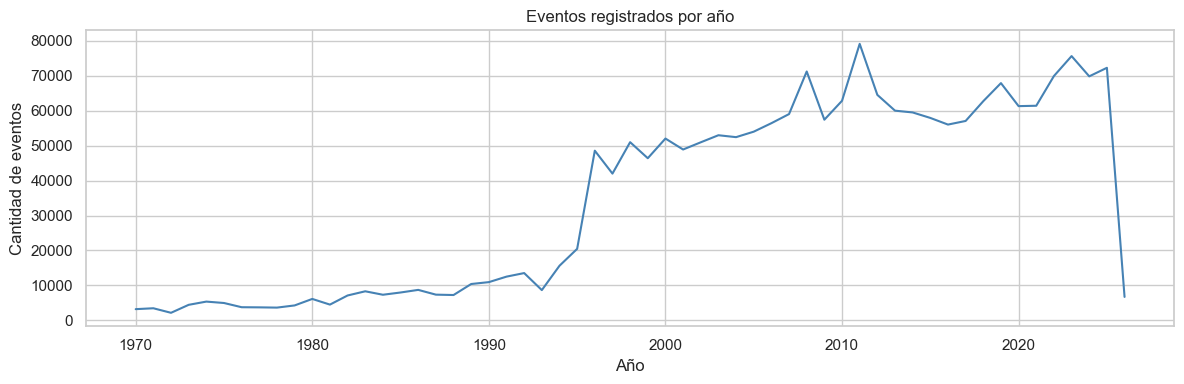

In [8]:
yearly = details.groupby('YEAR').size()
fig, ax = plt.subplots(figsize=(12, 4))
yearly.plot(ax=ax, color='steelblue')
ax.set_title('Eventos registrados por año')
ax.set_xlabel('Año'); ax.set_ylabel('Cantidad de eventos')
plt.tight_layout(); plt.show()

> Nota: el salto a partir de 1996 refleja el cambio de NOAA en la cobertura (antes solo tornados, granizo y vientos).

### 5.2 Top 15 tipos de evento

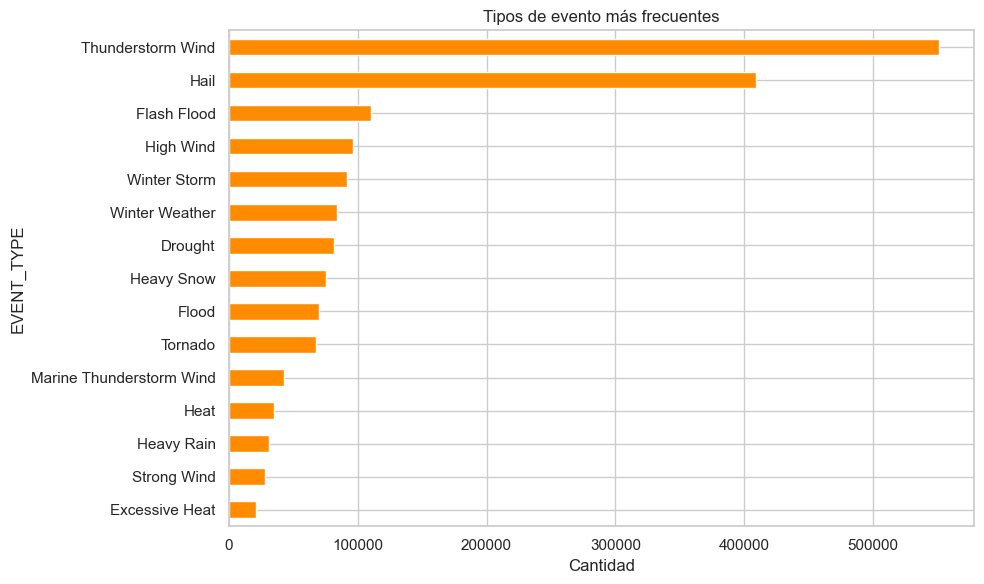

In [9]:
top_types = details['EVENT_TYPE'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(10, 6))
top_types.sort_values().plot.barh(ax=ax, color='darkorange')
ax.set_title('Tipos de evento más frecuentes')
ax.set_xlabel('Cantidad')
plt.tight_layout(); plt.show()

### 5.3 Estacionalidad

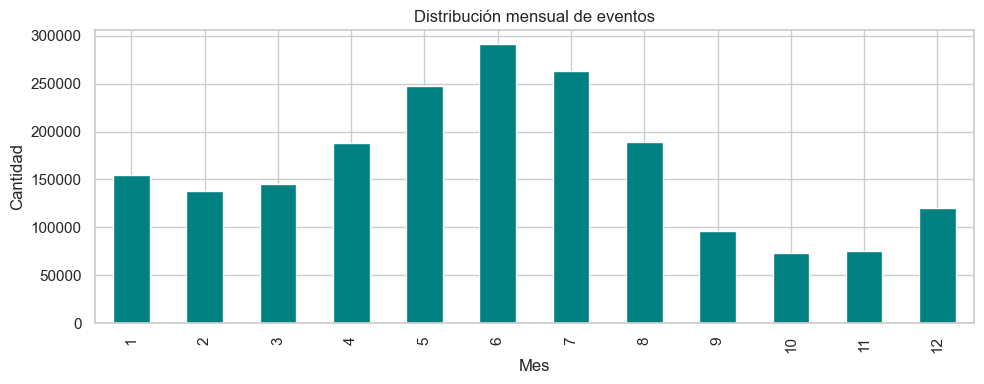

In [10]:
monthly = details.groupby('MONTH').size()
fig, ax = plt.subplots(figsize=(10, 4))
monthly.plot.bar(ax=ax, color='teal')
ax.set_title('Distribución mensual de eventos')
ax.set_xlabel('Mes'); ax.set_ylabel('Cantidad')
plt.tight_layout(); plt.show()

### 5.4 Daños económicos

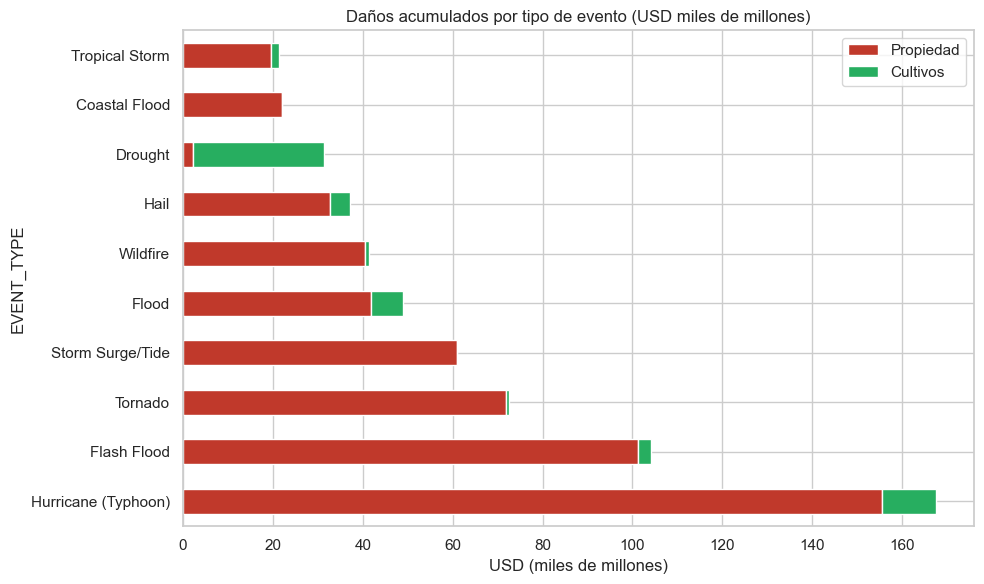

,DAMAGE_PROPERTY_USD,DAMAGE_CROPS_USD,TOTAL
EVENT_TYPE,,,
Hurricane (Typhoon),155.601029,12.033125,167.634154
Flash Flood,101.233428,2.794257,104.027684
Tornado,71.924179,0.523775,72.447954
Storm Surge/Tide,60.968115,0.000955,60.969070
Flood,41.771015,7.121078,48.892093
Wildfire,40.569482,0.710522,41.280004
Hail,32.759397,4.377658,37.137055
Drought,2.197558,29.118681,31.316239
Coastal Flood,21.931676,0.002810,21.934486


In [11]:
damage = (details.groupby('EVENT_TYPE')[['DAMAGE_PROPERTY_USD', 'DAMAGE_CROPS_USD']]
                 .sum()
                 .assign(TOTAL=lambda d: d.sum(axis=1))
                 .sort_values('TOTAL', ascending=False)
                 .head(10))
damage_b = damage / 1e9  # en miles de millones de USD

fig, ax = plt.subplots(figsize=(10, 6))
damage_b[['DAMAGE_PROPERTY_USD', 'DAMAGE_CROPS_USD']].plot.barh(
    stacked=True, ax=ax, color=['#c0392b', '#27ae60'])
ax.set_title('Daños acumulados por tipo de evento (USD miles de millones)')
ax.set_xlabel('USD (miles de millones)')
ax.legend(['Propiedad', 'Cultivos'])
plt.tight_layout(); plt.show()

damage_b

### 5.5 Víctimas

In [12]:
victim_cols = ['DEATHS_DIRECT', 'DEATHS_INDIRECT', 'INJURIES_DIRECT', 'INJURIES_INDIRECT']
victims = (details.groupby('EVENT_TYPE')[victim_cols]
                  .sum()
                  .assign(TOTAL_DEATHS=lambda d: d['DEATHS_DIRECT'] + d['DEATHS_INDIRECT'])
                  .sort_values('TOTAL_DEATHS', ascending=False)
                  .head(10))
victims

,DEATHS_DIRECT,DEATHS_INDIRECT,INJURIES_DIRECT,INJURIES_INDIRECT,TOTAL_DEATHS
EVENT_TYPE,,,,,
Tornado,3987,48,67548,291,4035
Heat,3248,749,10817,278,3997
Excessive Heat,2061,640,8035,84,2701
Flash Flood,2131,68,6521,75,2199
Rip Current,1395,9,985,19,1404
Hurricane (Typhoon),1218,166,1772,2481,1384
Thunderstorm Wind,1164,114,11759,427,1278
Winter Weather,198,888,2407,4164,1086
Lightning,954,54,5467,352,1008


### 5.6 Distribución geográfica

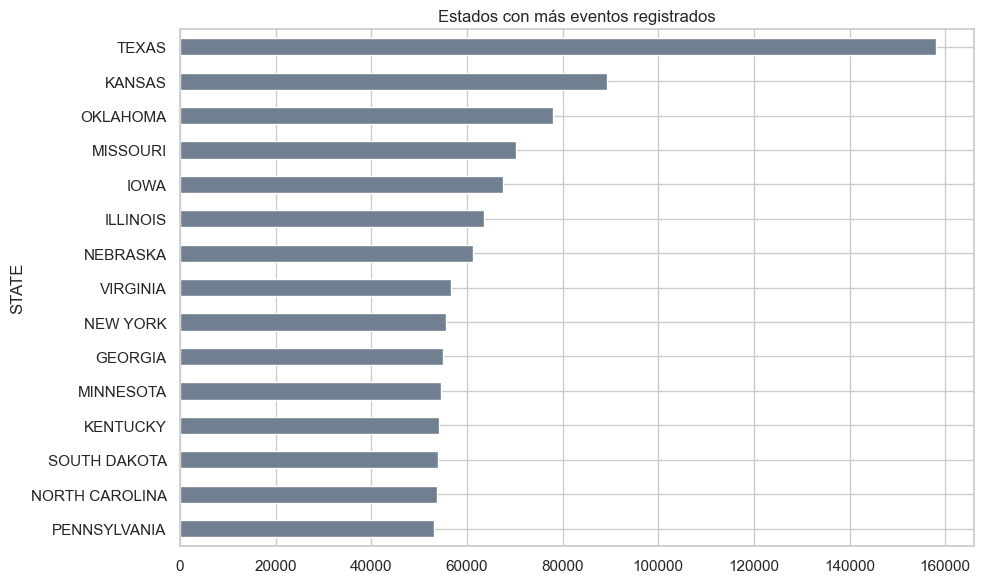

In [13]:
by_state = details['STATE'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(10, 6))
by_state.sort_values().plot.barh(ax=ax, color='slategray')
ax.set_title('Estados con más eventos registrados')
plt.tight_layout(); plt.show()

## 6. Merge con `locations` y `fatalities`

Se vinculan los tres DataFrames mediante `EVENT_ID`. Dado que un evento puede tener múltiples ubicaciones y víctimas, el resultado se mantiene en formato largo.

In [14]:
details_geo = details.merge(
    locations[['EVENT_ID', 'LATITUDE', 'LONGITUDE', 'LOCATION']],
    on='EVENT_ID', how='left')

details_fat = details.merge(
    fatalities[['EVENT_ID', 'FATALITY_TYPE', 'FATALITY_AGE', 'FATALITY_SEX', 'FATALITY_LOCATION']],
    on='EVENT_ID', how='inner')

print(f'details_geo: {len(details_geo):,} filas (eventos × ubicaciones)')
print(f'details_fat: {len(details_fat):,} filas (solo eventos con víctimas)')

details_geo: 2,477,640 filas (eventos × ubicaciones)
details_fat: 24,539 filas (solo eventos con víctimas)


## 8: Analisis de faltantes

In [15]:
# === Análisis de valores faltantes ===
missing = pd.DataFrame({
    'n_missing': details.isna().sum(),
    'pct_missing': (details.isna().mean() * 100).round(2),
    'dtype': details.dtypes.astype(str)
})
missing = missing[missing['n_missing'] > 0].sort_values('pct_missing', ascending=False)
print(f'Columnas con faltantes: {len(missing)} de {details.shape[1]}')
missing

Columnas con faltantes: 34 de 56


,n_missing,pct_missing,dtype
CATEGORY,1982774,99.97,float64
TOR_OTHER_WFO,1979585,99.81,object
TOR_OTHER_CZ_NAME,1979593,99.81,object
TOR_OTHER_CZ_STATE,1979585,99.81,object
TOR_OTHER_CZ_FIPS,1979593,99.81,float64
TOR_F_SCALE,1916171,96.61,str
FLOOD_CAUSE,1857215,93.64,object
TOR_WIDTH,1744520,87.96,float64
TOR_LENGTH,1744520,87.96,float64
MAGNITUDE_TYPE,1438447,72.53,object


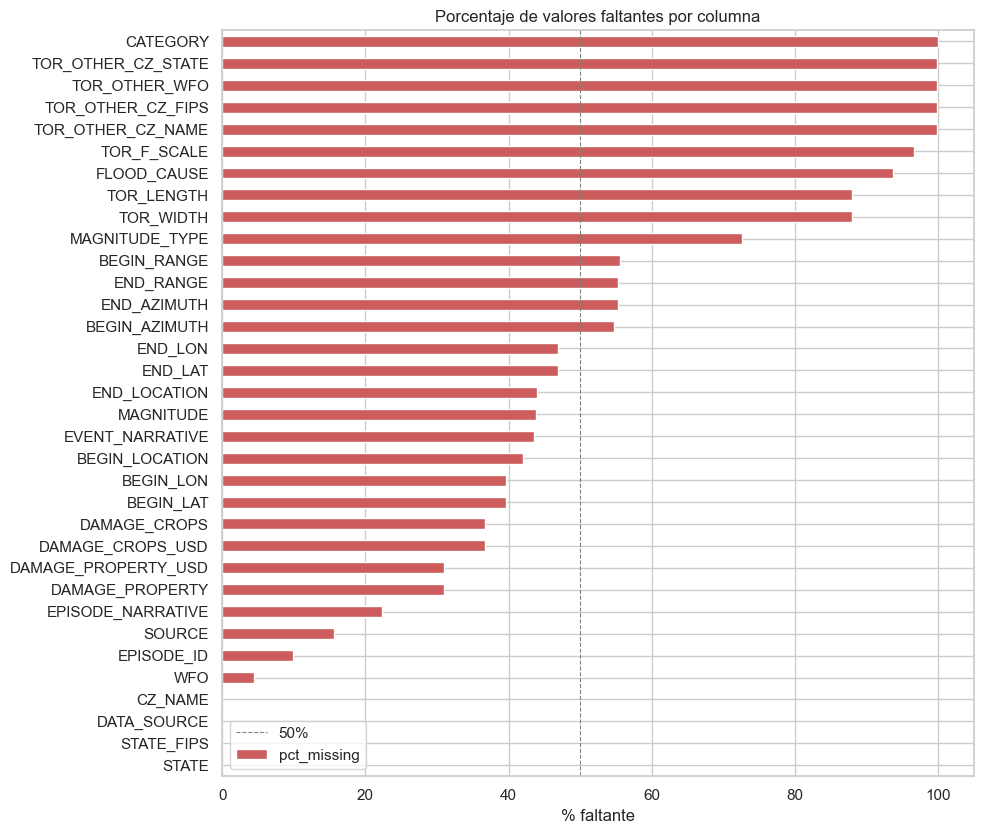

In [16]:
# Visualización
fig, ax = plt.subplots(figsize=(10, max(4, len(missing) * 0.25)))
missing['pct_missing'].sort_values().plot.barh(ax=ax, color='indianred')
ax.set_title('Porcentaje de valores faltantes por columna')
ax.set_xlabel('% faltante')
ax.axvline(50, color='gray', linestyle='--', linewidth=0.8, label='50%')
ax.legend()
plt.tight_layout(); plt.show()

In [17]:
# Faltantes condicionados al tipo de evento (los campos TOR_* sólo aplican a tornados)
tor_cols = [c for c in details.columns if c.startswith('TOR_')]
tornados = details[details['EVENT_TYPE'] == 'Tornado']
print(f'Eventos tipo Tornado: {len(tornados):,}')
print('\nFaltantes en campos TOR_ dentro de tornados:')
print((tornados[tor_cols].isna().mean() * 100).round(2).sort_values(ascending=False))

Eventos tipo Tornado: 67,843

Faltantes en campos TOR_ dentro de tornados:
TOR_OTHER_CZ_NAME     94.49
TOR_OTHER_CZ_FIPS     94.49
TOR_OTHER_CZ_STATE    94.47
TOR_OTHER_WFO         94.47
TOR_F_SCALE            1.01
TOR_WIDTH              0.00
TOR_LENGTH             0.00
dtype: float64


## 9. Seleccion de outliers

In [18]:
# === Outliers en variables numéricas clave ===
numeric_cols = ['INJURIES_DIRECT', 'INJURIES_INDIRECT',
                'DEATHS_DIRECT', 'DEATHS_INDIRECT',
                'DAMAGE_PROPERTY_USD', 'DAMAGE_CROPS_USD',
                'MAGNITUDE', 'TOR_LENGTH', 'TOR_WIDTH']

summary = details[numeric_cols].describe(percentiles=[.5, .9, .95, .99]).T
summary['skew'] = details[numeric_cols].skew()
summary

,count,mean,std,min,50%,90%,95%,99%,max,skew
INJURIES_DIRECT,1983334.0,0.066065,3.103756e+00,0.0,0.0,0.00,0.00,1.0,1.700000e+03,222.444378
INJURIES_INDIRECT,1983334.0,0.007981,1.810097e+00,0.0,0.0,0.00,0.00,0.0,2.400000e+03,1192.618608
DEATHS_DIRECT,1983334.0,0.010824,5.617217e-01,0.0,0.0,0.00,0.00,0.0,6.380000e+02,780.058595
DEATHS_INDIRECT,1983334.0,0.002307,9.404750e-02,0.0,0.0,0.00,0.00,0.0,5.600000e+01,190.196063
DAMAGE_PROPERTY_USD,1368445.0,436111.133282,3.591252e+07,0.0,0.0,20000.00,75000.00,1200000.0,1.790000e+10,274.203583
DAMAGE_CROPS_USD,1256430.0,56291.655487,3.093406e+06,0.0,0.0,0.00,0.00,50000.0,1.500000e+09,220.691296
MAGNITUDE,1114302.0,29.100141,3.464762e+01,0.0,40.0,60.00,62.00,74.0,2.200000e+04,234.158032
TOR_LENGTH,238814.0,0.891266,8.268994e+00,0.0,0.0,2.05,5.22,15.0,2.315000e+03,212.320925
TOR_WIDTH,238814.0,38.498447,1.429842e+02,0.0,0.0,100.00,200.00,700.0,4.576000e+03,8.361737


In [19]:
# Conteo de outliers por método IQR
def iqr_outliers(series):
    s = series.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n = ((s < lo) | (s > hi)).sum()
    return pd.Series({'n_outliers': n,
                      'pct_outliers': round(n / len(s) * 100, 2),
                      'low_bound': lo, 'high_bound': hi})

outlier_report = pd.DataFrame({c: iqr_outliers(details[c]) for c in numeric_cols}).T
outlier_report

,n_outliers,pct_outliers,low_bound,high_bound
INJURIES_DIRECT,19886.0,1.00,0.00,0.00
INJURIES_INDIRECT,2954.0,0.15,0.00,0.00
DEATHS_DIRECT,11726.0,0.59,0.00,0.00
DEATHS_INDIRECT,2966.0,0.15,0.00,0.00
DAMAGE_PROPERTY_USD,228381.0,16.69,-3000.00,5000.00
DAMAGE_CROPS_USD,38847.0,3.09,0.00,0.00
MAGNITUDE,101.0,0.01,-75.50,128.50
TOR_LENGTH,49209.0,20.61,-0.15,0.25
TOR_WIDTH,30093.0,12.60,-30.00,50.00


In [20]:
# Top 10 eventos más extremos por daño y por víctimas
print('=== Top 10 eventos por daño a la propiedad ===')
cols_show = ['BEGIN_DATE_TIME', 'STATE', 'EVENT_TYPE',
             'DAMAGE_PROPERTY_USD', 'DEATHS_DIRECT', 'INJURIES_DIRECT']
top_damage = details.nlargest(10, 'DAMAGE_PROPERTY_USD')[cols_show]
print(top_damage.to_string())

print('\n=== Top 10 eventos por muertes directas ===')
top_deaths = details.nlargest(10, 'DEATHS_DIRECT')[cols_show]
print(top_deaths.to_string())

=== Top 10 eventos por daño a la propiedad ===
            BEGIN_DATE_TIME       STATE           EVENT_TYPE  DAMAGE_PROPERTY_USD  DEATHS_DIRECT  INJURIES_DIRECT
679205  2005-08-29 02:00:00   LOUISIANA     Storm Surge/Tide         1.790000e+10              0                0
1469096 2018-11-08 06:33:00  CALIFORNIA             Wildfire         1.700000e+10             86               12
692473  2005-10-24 07:00:00     FLORIDA  Hurricane (Typhoon)         1.000000e+10              1                0
1433655 2017-08-26 22:00:00       TEXAS          Flash Flood         1.000000e+10              3                0
1434270 2017-08-26 21:45:00       TEXAS          Flash Flood         1.000000e+10             36                0
1433489 2017-08-26 18:40:00       TEXAS          Flash Flood         8.000000e+09              3                0
1100803 2012-10-29 05:00:00  NEW JERSEY        Coastal Flood         7.500000e+09              0                0
1433651 2017-08-27 20:00:00       TEXAS  

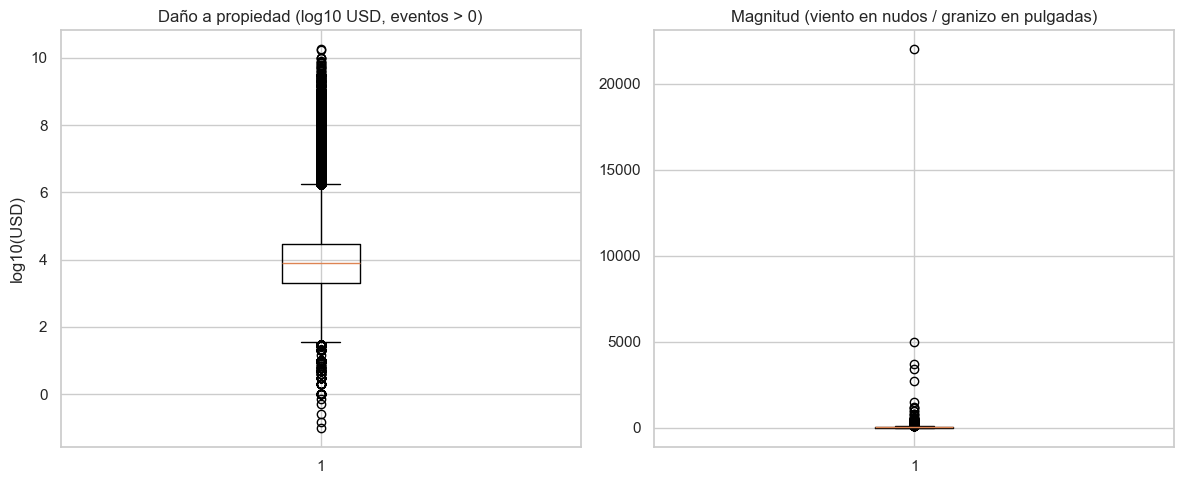

In [21]:
# Boxplots en escala logarítmica (los daños son altamente asimétricos)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

dmg = details.loc[details['DAMAGE_PROPERTY_USD'] > 0, 'DAMAGE_PROPERTY_USD']
axes[0].boxplot(np.log10(dmg), vert=True)
axes[0].set_title('Daño a propiedad (log10 USD, eventos > 0)')
axes[0].set_ylabel('log10(USD)')

mag = details['MAGNITUDE'].dropna()
axes[1].boxplot(mag, vert=True)
axes[1].set_title('Magnitud (viento en nudos / granizo en pulgadas)')

plt.tight_layout(); plt.show()

## 9.bis Análisis de faltantes en variables de daño

Antes de construir cualquier target basado en daño económico, es imprescindible distinguir entre **daño cero** (el evento no causó daño) y **daño no reportado** (faltante genuino). Tras la corrección del parseo, los vacíos se conservan como `NaN` en las columnas `*_USD`.

> **Nota metodológica:** la detección de faltantes se hace con `.isna()` sobre las columnas `*_USD` ya parseadas, no comparando texto sobre las columnas crudas. Las columnas originales son de tipo `string` y sus nulos (`pd.NA`) no se detectan de forma fiable con `.astype(str)`, lo que produciría un falso 0% de faltantes. De este modo los números coinciden con la sección 8.

In [22]:
# === 1. Faltante (no reportado) vs. cero explícito en las columnas de daño ===
# Usamos las columnas *_USD ya parseadas: NaN = no reportado, 0.0 = cero explícito.
# (Comparar strings con .astype(str) NO detecta pd.NA correctamente -> da 0% falso.)
for col in ['DAMAGE_PROPERTY', 'DAMAGE_CROPS']:
    usd = details[f'{col}_USD']
    n_missing = usd.isna().sum()
    n_zero    = (usd == 0).sum()
    n_valid   = (usd > 0).sum()
    print(f'{col}:')
    print(f'  No reportado (NaN) : {n_missing:>9,} ({n_missing/len(details)*100:5.1f}%)')
    print(f'  Cero explícito     : {n_zero:>9,} ({n_zero/len(details)*100:5.1f}%)')
    print(f'  Valor > 0          : {n_valid:>9,} ({n_valid/len(details)*100:5.1f}%)\n')

# Coherencia con la sección 8: estos NaN deben coincidir con los de details.isna()
print('Chequeo de coherencia con sección 8:')
for col in ['DAMAGE_PROPERTY_USD', 'DAMAGE_CROPS_USD']:
    print(f'  {col}: {details[col].isna().sum():,} NaN '
          f'({details[col].isna().mean()*100:.1f}%)')

DAMAGE_PROPERTY:
  No reportado (NaN) :   614,889 ( 31.0%)
  Cero explícito     :   931,571 ( 47.0%)
  Valor > 0          :   436,874 ( 22.0%)

DAMAGE_CROPS:
  No reportado (NaN) :   726,904 ( 36.7%)
  Cero explícito     : 1,217,583 ( 61.4%)
  Valor > 0          :    38,847 (  2.0%)

Chequeo de coherencia con sección 8:
  DAMAGE_PROPERTY_USD: 614,889 NaN (31.0%)
  DAMAGE_CROPS_USD: 726,904 NaN (36.7%)


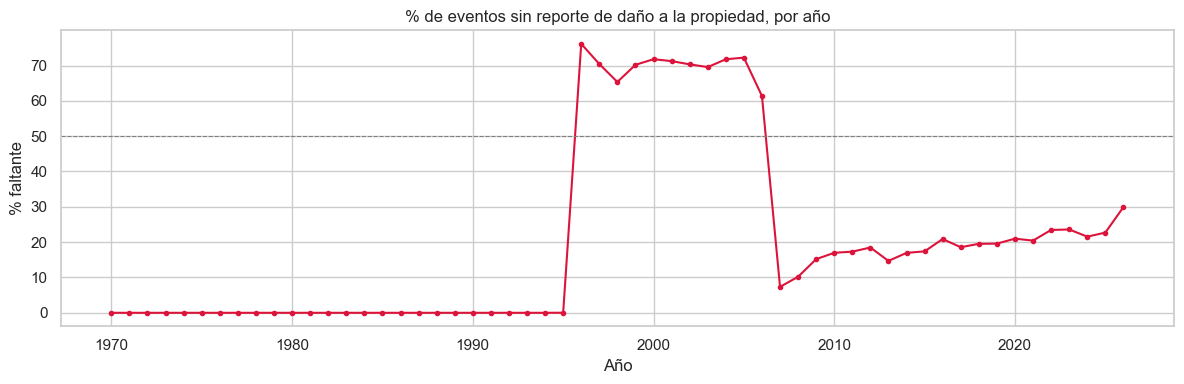

In [23]:
# === 2. Evolución temporal del reporte de daño ===
# _missing = True cuando el daño a la propiedad NO fue reportado (NaN en la col parseada)
tmp = details.assign(_missing=details['DAMAGE_PROPERTY_USD'].isna())
missing_by_year = tmp.groupby('YEAR')['_missing'].mean() * 100

fig, ax = plt.subplots(figsize=(12, 4))
missing_by_year.plot(ax=ax, color='crimson', marker='o', markersize=3)
ax.set_title('% de eventos sin reporte de daño a la propiedad, por año')
ax.set_xlabel('Año'); ax.set_ylabel('% faltante')
ax.axhline(50, color='gray', linestyle='--', linewidth=0.8)
plt.tight_layout(); plt.show()

In [24]:
# === 3. ¿El faltante de daño depende del tipo de evento? ===
tmp = details.assign(_missing=details['DAMAGE_PROPERTY_USD'].isna())
missing_by_type = (tmp.groupby('EVENT_TYPE')['_missing']
                      .agg(pct_missing='mean', n='size'))
missing_by_type['pct_missing'] *= 100
missing_by_type = missing_by_type.sort_values('pct_missing', ascending=False)

print('Tipos de evento con mayor % de daño NO reportado (top 15):')
print(missing_by_type.head(15).round(1))
print('\nTipos con MENOR % de faltante (mejor cobertura):')
print(missing_by_type.tail(10).round(1))

Tipos de evento con mayor % de daño NO reportado (top 15):
                  pct_missing       n
EVENT_TYPE                           
Northern Lights         100.0       8
Volcanic Ash             92.9      70
Cold/Wind Chill          54.3   18782
Sleet                    51.8     859
Ice Storm                47.0   12632
Heat                     46.1   34898
Heavy Snow               45.4   75693
Blizzard                 42.5   17040
Marine Hail              41.8     856
Winter Storm             41.8   91543
Drought                  41.3   81886
Waterspout               41.0    6235
Hail                     40.3  408868
Dense Fog                39.6   17576
Storm Surge/Tide         39.1    1656

Tipos con MENOR % de faltante (mejor cobertura):
                            pct_missing    n
EVENT_TYPE                                  
Marine High Wind                    9.5  976
Marine Tropical Storm               9.3  603
Marine Strong Wind                  7.2  166
Lakeshore Flood     

### Lectura e implicancias

Las celdas anteriores responden a las preguntas que condicionan el diseño del target:

1. **No reportado vs. cero**: si la proporción de no reportados es alta, no se puede tratar el faltante como "Sin daño".
2. **Evolución temporal**: si el reporte cambia bruscamente en el tiempo, un split temporal de train/test mezclaría definiciones distintas de la clase base.
3. **Por tipo de evento**: algunos tipos (p. ej. eventos marinos o de baja visibilidad) casi nunca reportan daño y podrían requerir tratamiento aparte.

A partir de estos números se elige una de tres estrategias: (a) tratar el faltante como "Sin daño", (b) excluir los no reportados del problema de daño, o (c) modelar en dos etapas (primero "¿hubo daño?", luego magnitud condicionada). La decisión se toma con los datos a la vista, antes de construir el target.

## 10. Feature Engineering

In [25]:
# === Feature Engineering: setup ===
# Trabajamos sobre una copia para no contaminar el DataFrame original
df = details.copy()
print(f'Filas: {len(df):,} | Columnas iniciales: {df.shape[1]}')

Filas: 1,983,334 | Columnas iniciales: 56


In [26]:
# === 10.1 Features temporales ===
df['HOUR']         = df['BEGIN_DATE_TIME'].dt.hour
df['DAY_OF_WEEK']  = df['BEGIN_DATE_TIME'].dt.dayofweek      # 0 = lunes
df['DAY_OF_YEAR']  = df['BEGIN_DATE_TIME'].dt.dayofyear
df['IS_WEEKEND']   = df['DAY_OF_WEEK'].isin([5, 6]).astype(int)
df['DECADE']       = (df['YEAR'] // 10 * 10).astype('Int64')

# Estación meteorológica del hemisferio norte
def get_season(month):
    if month in (12, 1, 2):  return 'Winter'
    if month in (3, 4, 5):   return 'Spring'
    if month in (6, 7, 8):   return 'Summer'
    return 'Fall'
df['SEASON'] = df['MONTH'].apply(get_season)

# Franja horaria
def time_of_day(h):
    if pd.isna(h):       return np.nan
    if 0  <= h < 6:      return 'Night'
    if 6  <= h < 12:     return 'Morning'
    if 12 <= h < 18:     return 'Afternoon'
    return 'Evening'
df['TIME_OF_DAY'] = df['HOUR'].apply(time_of_day)

# Duración del evento en minutos (con cap superior para evitar outliers extremos)
duration = (df['END_DATE_TIME'] - df['BEGIN_DATE_TIME']).dt.total_seconds() / 60
df['DURATION_MIN'] = duration.clip(lower=0, upper=duration.quantile(0.999))

# Indicador de era post-1996 (cuando NOAA expandió la cobertura)
df['POST_1996'] = (df['YEAR'] >= 1996).astype(int)

print('Features temporales agregadas:')
print(df[['HOUR', 'DAY_OF_WEEK', 'IS_WEEKEND', 'SEASON', 'TIME_OF_DAY',
          'DURATION_MIN', 'DECADE', 'POST_1996']].head())

Features temporales agregadas:
   HOUR  DAY_OF_WEEK  IS_WEEKEND  SEASON TIME_OF_DAY  DURATION_MIN  DECADE  \
0    16            4           0    Fall   Afternoon           0.0    1970   
1    16            3           0    Fall   Afternoon           0.0    1970   
2    16            3           0  Summer   Afternoon           0.0    1970   
3    22            3           0  Summer     Evening           0.0    1970   
4    21            2           0  Summer     Evening           0.0    1970   

   POST_1996  
0          0  
1          0  
2          0  
3          0  
4          0  


In [27]:
# === 10.2 Features geográficas ===

# Región climática a partir del estado
REGION_MAP = {
    # Tornado Alley
    'TEXAS': 'Tornado Alley', 'OKLAHOMA': 'Tornado Alley', 'KANSAS': 'Tornado Alley',
    'NEBRASKA': 'Tornado Alley', 'SOUTH DAKOTA': 'Tornado Alley',
    # Dixie Alley / Sureste
    'MISSISSIPPI': 'Southeast', 'ALABAMA': 'Southeast', 'GEORGIA': 'Southeast',
    'TENNESSEE': 'Southeast', 'ARKANSAS': 'Southeast', 'LOUISIANA': 'Southeast',
    'FLORIDA': 'Southeast', 'SOUTH CAROLINA': 'Southeast', 'NORTH CAROLINA': 'Southeast',
    # Medio Oeste
    'MISSOURI': 'Midwest', 'IOWA': 'Midwest', 'ILLINOIS': 'Midwest',
    'INDIANA': 'Midwest', 'OHIO': 'Midwest', 'MICHIGAN': 'Midwest',
    'WISCONSIN': 'Midwest', 'MINNESOTA': 'Midwest', 'NORTH DAKOTA': 'Midwest',
    # Noreste
    'NEW YORK': 'Northeast', 'PENNSYLVANIA': 'Northeast', 'NEW JERSEY': 'Northeast',
    'MASSACHUSETTS': 'Northeast', 'CONNECTICUT': 'Northeast', 'MAINE': 'Northeast',
    'NEW HAMPSHIRE': 'Northeast', 'VERMONT': 'Northeast', 'RHODE ISLAND': 'Northeast',
    'MARYLAND': 'Northeast', 'DELAWARE': 'Northeast', 'VIRGINIA': 'Northeast',
    'WEST VIRGINIA': 'Northeast', 'DISTRICT OF COLUMBIA': 'Northeast',
    # Oeste / Montañas
    'COLORADO': 'West', 'WYOMING': 'West', 'MONTANA': 'West', 'IDAHO': 'West',
    'UTAH': 'West', 'NEVADA': 'West', 'ARIZONA': 'West', 'NEW MEXICO': 'West',
    'CALIFORNIA': 'West Coast', 'OREGON': 'West Coast', 'WASHINGTON': 'West Coast',
    # No contiguos
    'ALASKA': 'Non-Contiguous', 'HAWAII': 'Non-Contiguous',
    # Otros
    'KENTUCKY': 'Southeast',
}
df['REGION'] = df['STATE'].map(REGION_MAP).fillna('Other/Marine')

# Indicador marítimo (eventos sobre zonas oceánicas o grandes lagos)
df['IS_MARINE'] = (df['CZ_TYPE'] == 'M').astype(int)

# Indicador de zona forecast vs condado (Z = área más amplia)
df['IS_ZONE_FORECAST'] = (df['CZ_TYPE'] == 'Z').astype(int)

# Distancia haversine entre punto de inicio y fin (cuando ambos existen)
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

mask = df[['BEGIN_LAT', 'BEGIN_LON', 'END_LAT', 'END_LON']].notna().all(axis=1)
df['TRACK_DISTANCE_KM'] = np.nan
df.loc[mask, 'TRACK_DISTANCE_KM'] = haversine_km(
    df.loc[mask, 'BEGIN_LAT'], df.loc[mask, 'BEGIN_LON'],
    df.loc[mask, 'END_LAT'],   df.loc[mask, 'END_LON']
)

# Grid geográfico de 1° × 1° (reduce cardinalidad de lat/lon)
df['LAT_BIN'] = df['BEGIN_LAT'].round(0)
df['LON_BIN'] = df['BEGIN_LON'].round(0)

print('Distribución por región:')
print(df['REGION'].value_counts())

Distribución por región:
REGION
Midwest           459496
Southeast         441603
Tornado Alley     440813
Northeast         311364
West              183676
West Coast         62398
Other/Marine       59022
Non-Contiguous     24962
Name: count, dtype: int64


In [28]:
# === 10.3 Features físicas ===

# Severidad ordinal del tornado a partir de TOR_F_SCALE
def parse_fscale(s):
    if pd.isna(s): return np.nan
    s = str(s).upper().replace('EF', '').replace('F', '').strip()
    try: return int(s)
    except ValueError: return np.nan
df['TOR_SCALE_NUM'] = df['TOR_F_SCALE'].apply(parse_fscale)

# Área aproximada barrida por el tornado (millas × yardas → km²)
# 1 milla = 1.609 km; 1 yarda = 0.000914 km
df['TOR_AREA_KM2'] = (df['TOR_LENGTH'] * 1.609) * (df['TOR_WIDTH'] * 0.000914)

# Indicadores de presencia (los faltantes son estructurales, no errores)
df['HAS_MAGNITUDE']    = df['MAGNITUDE'].notna().astype(int)
df['HAS_TORNADO_DATA'] = df['TOR_SCALE_NUM'].notna().astype(int)
df['HAS_CATEGORY']     = df['CATEGORY'].notna().astype(int)
df['HAS_COORDINATES']  = df['BEGIN_LAT'].notna().astype(int)

# Magnitud normalizada dentro del tipo de evento (z-score por EVENT_TYPE)
# Útil porque un valor de 50 significa cosas distintas en viento (nudos) vs granizo (pulgadas)
def zscore_within_group(s):
    if s.std(ddof=0) == 0 or s.notna().sum() < 2:
        return pd.Series(np.nan, index=s.index)
    return (s - s.mean()) / s.std(ddof=0)

df['MAGNITUDE_ZSCORE'] = (
    df.groupby('EVENT_TYPE')['MAGNITUDE']
      .transform(zscore_within_group)
)

print('Resumen de features físicas:')
print(df[['TOR_SCALE_NUM', 'TOR_AREA_KM2', 'MAGNITUDE_ZSCORE',
          'HAS_MAGNITUDE', 'HAS_TORNADO_DATA']].describe())

Resumen de features físicas:
       TOR_SCALE_NUM   TOR_AREA_KM2  MAGNITUDE_ZSCORE  HAS_MAGNITUDE  \
count   65534.000000  238814.000000      1.114298e+06   1.983334e+06   
mean        0.761391       0.378842     -2.350668e-16   5.618328e-01   
std         0.906202       2.811578      1.000000e+00   4.961621e-01   
min         0.000000       0.000000     -7.923741e+00   0.000000e+00   
25%         0.000000       0.000000     -3.824255e-01   0.000000e+00   
50%         1.000000       0.000000      1.711442e-01   1.000000e+00   
75%         1.000000       0.002941      4.728788e-01   1.000000e+00   
max         5.000000     182.475274      1.433995e+02   1.000000e+00   

       HAS_TORNADO_DATA  
count      1.983334e+06  
mean       3.304234e-02  
std        1.787472e-01  
min        0.000000e+00  
25%        0.000000e+00  
50%        0.000000e+00  
75%        0.000000e+00  
max        1.000000e+00  


In [29]:
# === 10.4 Features derivadas de impacto ===
# Estas son útiles como TARGET potencial o como features para problemas relacionados.
# OJO: si las usás como features, asegurate de que el target no las contenga (leakage circular).

df['TOTAL_DEATHS']     = df['DEATHS_DIRECT'] + df['DEATHS_INDIRECT']
df['TOTAL_INJURIES']   = df['INJURIES_DIRECT'] + df['INJURIES_INDIRECT']
df['TOTAL_CASUALTIES'] = df['TOTAL_DEATHS'] + df['TOTAL_INJURIES']

# --- Daño total: se PRESERVAN los faltantes (no se aplastan a 0) ---
# Un evento se considera "con daño reportado" si AL MENOS una de las dos
# componentes (propiedad o cultivos) fue reportada. La suma ignora el NaN
# de la otra componente, pero si AMBAS son NaN el total queda NaN.
prop = df['DAMAGE_PROPERTY_USD']
crop = df['DAMAGE_CROPS_USD']
df['DAMAGE_REPORTED'] = prop.notna() | crop.notna()
df['TOTAL_DAMAGE_USD'] = prop.add(crop, fill_value=0)
df.loc[~df['DAMAGE_REPORTED'], 'TOTAL_DAMAGE_USD'] = np.nan  # ambas faltantes -> NaN

# Transformaciones log (solo definidas donde hubo reporte)
df['LOG_DAMAGE_PROPERTY'] = np.log1p(df['DAMAGE_PROPERTY_USD'])
df['LOG_TOTAL_DAMAGE']    = np.log1p(df['TOTAL_DAMAGE_USD'])

# Indicadores binarios listos para usar como targets en distintos problemas
df['HAS_FATALITIES']     = (df['TOTAL_DEATHS'] > 0).astype(int)
df['HAS_CASUALTIES']     = (df['TOTAL_CASUALTIES'] > 0).astype(int)
df['IS_VIOLENT_TORNADO'] = (df['TOR_SCALE_NUM'] >= 3).astype('Int64')
# IS_MAJOR_DAMAGE solo se define donde hubo reporte (NaN si no se reportó)
df['IS_MAJOR_DAMAGE'] = np.where(
    df['DAMAGE_REPORTED'], (df['TOTAL_DAMAGE_USD'] >= 1_000_000).astype(float), np.nan
)

print('Tasas base de potenciales targets:')
for col in ['HAS_FATALITIES', 'HAS_CASUALTIES']:
    print(f'  {col:20s}: {df[col].mean()*100:.2f}%')

# IS_MAJOR_DAMAGE: tasa calculada SOLO sobre eventos con daño reportado
rep = df['DAMAGE_REPORTED']
print(f'  IS_MAJOR_DAMAGE (entre reportados): '
      f'{df.loc[rep, "IS_MAJOR_DAMAGE"].mean()*100:.2f}% '
      f'(reportados: {rep.sum():,} / {len(df):,})')

tornado_mask = df['HAS_TORNADO_DATA'] == 1
print(f'  IS_VIOLENT_TORNADO (entre tornados): '
      f'{df.loc[tornado_mask, "IS_VIOLENT_TORNADO"].mean()*100:.2f}%')

Tasas base de potenciales targets:
  HAS_FATALITIES      : 0.72%
  HAS_CASUALTIES      : 1.68%
  IS_MAJOR_DAMAGE (entre reportados): 1.52% (reportados: 1,407,565 / 1,983,334)
  IS_VIOLENT_TORNADO (entre tornados): 5.08%


In [30]:
# === Resumen de features creadas ===
new_features = [
    # Temporales
    'HOUR', 'DAY_OF_WEEK', 'DAY_OF_YEAR', 'IS_WEEKEND', 'DECADE',
    'SEASON', 'TIME_OF_DAY', 'DURATION_MIN', 'POST_1996',
    # Geográficas
    'REGION', 'IS_MARINE', 'IS_ZONE_FORECAST', 'TRACK_DISTANCE_KM',
    'LAT_BIN', 'LON_BIN',
    # Físicas
    'TOR_SCALE_NUM', 'TOR_AREA_KM2', 'MAGNITUDE_ZSCORE',
    'HAS_MAGNITUDE', 'HAS_TORNADO_DATA', 'HAS_CATEGORY', 'HAS_COORDINATES',
    # Impacto / targets candidatos
    'TOTAL_DEATHS', 'TOTAL_INJURIES', 'TOTAL_CASUALTIES', 'TOTAL_DAMAGE_USD',
    'LOG_DAMAGE_PROPERTY', 'LOG_TOTAL_DAMAGE',
    'HAS_FATALITIES', 'HAS_CASUALTIES', 'IS_VIOLENT_TORNADO', 'IS_MAJOR_DAMAGE',
]

print(f'Total de features nuevas: {len(new_features)}')
print(f'Dimensiones finales del DataFrame: {df.shape}')
print('\nFaltantes en las nuevas features:')
print(df[new_features].isna().mean().mul(100).round(2).sort_values(ascending=False).head(15))


Total de features nuevas: 32
Dimensiones finales del DataFrame: (1983334, 89)

Faltantes en las nuevas features:
TOR_SCALE_NUM          96.70
TOR_AREA_KM2           87.96
TRACK_DISTANCE_KM      46.94
MAGNITUDE_ZSCORE       43.82
LAT_BIN                39.59
LON_BIN                39.59
LOG_DAMAGE_PROPERTY    31.00
TOTAL_DAMAGE_USD       29.03
LOG_TOTAL_DAMAGE       29.03
IS_MAJOR_DAMAGE        29.03
DURATION_MIN            0.00
TIME_OF_DAY             0.00
HOUR                    0.00
DAY_OF_WEEK             0.00
DAY_OF_YEAR             0.00
dtype: float64


In [31]:
# === Exploración de variables categóricas ===
cat_cols = ['STATE', 'EVENT_TYPE', 'CZ_TYPE', 'REGION', 'SEASON',
            'TIME_OF_DAY', 'MONTH_NAME', 'WFO', 'SOURCE',
            'MAGNITUDE_TYPE', 'FLOOD_CAUSE', 'TOR_F_SCALE']
cat_cols = [c for c in cat_cols if c in df.columns]

resumen = pd.DataFrame({
    'cardinalidad': [df[c].nunique() for c in cat_cols],
    'pct_faltante': [df[c].isna().mean()*100 for c in cat_cols],
    'top_valor':    [df[c].mode().iat[0] if df[c].notna().any() else None for c in cat_cols],
    'pct_top':      [df[c].value_counts(normalize=True).iat[0]*100 if df[c].notna().any() else 0
                     for c in cat_cols],
}, index=cat_cols).sort_values('cardinalidad', ascending=False)

print(resumen.round(1))


                cardinalidad  pct_faltante          top_valor  pct_top
WFO                      541           4.5                LWX      2.9
SOURCE                    74          15.6    Trained Spotter     11.3
STATE                     69           0.0              TEXAS      8.0
EVENT_TYPE                56           0.0  Thunderstorm Wind     27.8
TOR_F_SCALE               13          96.6                 F0     27.7
MONTH_NAME                12           0.0               June     14.7
REGION                     8           0.0            Midwest     23.2
FLOOD_CAUSE                7          93.6         Heavy Rain     90.7
MAGNITUDE_TYPE             6          72.5                 EG     66.3
SEASON                     4           0.0             Summer     37.5
TIME_OF_DAY                4           0.0          Afternoon     38.0
CZ_TYPE                    3           0.0                  C     63.3


In [33]:
# === Ajuste por inflación: CPI-U promedio anual, base 2025 ===
CPI_U = {
    1970: 38.8, 1971: 40.5, 1972: 41.8, 1973: 44.4, 1974: 49.3, 1975: 53.8,
    1976: 56.9, 1977: 60.6, 1978: 65.2, 1979: 72.6, 1980: 82.4, 1981: 90.9,
    1982: 96.5, 1983: 99.6, 1984: 103.9, 1985: 107.6, 1986: 109.6, 1987: 113.6,
    1988: 118.3, 1989: 124.0, 1990: 130.7, 1991: 136.2, 1992: 140.3, 1993: 144.5,
    1994: 148.2, 1995: 152.4, 1996: 156.9, 1997: 160.5, 1998: 163.0, 1999: 166.6,
    2000: 172.2, 2001: 177.1, 2002: 179.9, 2003: 184.0, 2004: 188.9, 2005: 195.3,
    2006: 201.6, 2007: 207.3, 2008: 215.3, 2009: 214.5, 2010: 218.1, 2011: 224.9,
    2012: 229.6, 2013: 233.0, 2014: 236.7, 2015: 237.0, 2016: 240.0, 2017: 245.1,
    2018: 251.1, 2019: 255.7, 2020: 258.8, 2021: 271.0, 2022: 292.7, 2023: 304.7,
    2024: 313.7, 2025: 322.1, 2026: 322.1,
}
CPI_BASE = CPI_U[2025]

# OJO: usar df['YEAR']; si ya la borraste, reconstruila desde BEGIN_DATE_TIME
year = df['YEAR'] if 'YEAR' in df.columns else df['BEGIN_DATE_TIME'].dt.year
cpi = year.map(CPI_U).fillna(CPI_BASE)

df['DAMAGE_REAL_2025'] = df['TOTAL_DAMAGE_USD'] * (CPI_BASE / cpi)

mask = df['TOTAL_DAMAGE_USD'] > 0
print(df.loc[mask, ['TOTAL_DAMAGE_USD', 'DAMAGE_REAL_2025']].describe(percentiles=[.5,.9,.99]).round(0))

       TOTAL_DAMAGE_USD  DAMAGE_REAL_2025
count      4.521980e+05      4.521980e+05
mean       1.476169e+06      2.320288e+06
std        6.285468e+07      9.213520e+07
min        0.000000e+00      0.000000e+00
50%        1.000000e+04      1.244600e+04
90%        2.500000e+05      3.580880e+05
99%        1.025000e+07      1.813626e+07
max        1.790000e+10      2.952171e+10


In [34]:
# === Selección de features y separación del target ===

# 1. Monto de daño: se CONSERVA aparte para construir el target después (no es feature)
y_damage = df['DAMAGE_REAL_2025'].copy()   # monto ajustado por inflación

# 2. Columnas a excluir de las features
leakage = ['DAMAGE_PROPERTY', 'DAMAGE_CROPS', 'DAMAGE_PROPERTY_USD',
           'DAMAGE_CROPS_USD', 'TOTAL_DAMAGE_USD', 'DAMAGE_REAL_2025',
           'LOG_DAMAGE_PROPERTY', 'LOG_TOTAL_DAMAGE', 'IS_MAJOR_DAMAGE',
           'DAMAGE_REPORTED', 'DAMAGE_PROPERTY_REPORTED', 'DAMAGE_CROPS_REPORTED']

redundantes = ['MONTH_NAME', 'SEASON', 'STATE', 'WFO', 'YEAR']  # REGION y MONTH quedan

ids_texto = ['EVENT_ID', 'EPISODE_ID', 'EPISODE_NARRATIVE', 'EVENT_NARRATIVE',
             'BEGIN_LOCATION', 'END_LOCATION', 'BEGIN_AZIMUTH', 'END_AZIMUTH']

fechas_crudas = ['BEGIN_YEARMONTH', 'END_YEARMONTH', 'BEGIN_DAY', 'END_DAY',
                 'BEGIN_TIME', 'END_TIME', 'BEGIN_DATE_TIME', 'END_DATE_TIME']

# Otros targets candidatos (no son features de este problema)
otros_targets = ['HAS_FATALITIES', 'HAS_CASUALTIES', 'IS_VIOLENT_TORNADO',
                 'TOTAL_DEATHS', 'TOTAL_INJURIES', 'TOTAL_CASUALTIES',
                 'DEATHS_DIRECT', 'DEATHS_INDIRECT', 'INJURIES_DIRECT', 'INJURIES_INDIRECT']

to_drop = leakage + redundantes + ids_texto + fechas_crudas + otros_targets
to_drop = [c for c in to_drop if c in df.columns]

X = df.drop(columns=to_drop)
print(f'Features restantes: {X.shape[1]}')
print(sorted(X.columns))

Features restantes: 47
['BEGIN_LAT', 'BEGIN_LON', 'BEGIN_RANGE', 'CATEGORY', 'CZ_FIPS', 'CZ_NAME', 'CZ_TIMEZONE', 'CZ_TYPE', 'DATA_SOURCE', 'DAY_OF_WEEK', 'DAY_OF_YEAR', 'DECADE', 'DURATION_MIN', 'END_LAT', 'END_LON', 'END_RANGE', 'EVENT_TYPE', 'FLOOD_CAUSE', 'HAS_CATEGORY', 'HAS_COORDINATES', 'HAS_MAGNITUDE', 'HAS_TORNADO_DATA', 'HOUR', 'IS_MARINE', 'IS_WEEKEND', 'IS_ZONE_FORECAST', 'LAT_BIN', 'LON_BIN', 'MAGNITUDE', 'MAGNITUDE_TYPE', 'MAGNITUDE_ZSCORE', 'MONTH', 'POST_1996', 'REGION', 'SOURCE', 'STATE_FIPS', 'TIME_OF_DAY', 'TOR_AREA_KM2', 'TOR_F_SCALE', 'TOR_LENGTH', 'TOR_OTHER_CZ_FIPS', 'TOR_OTHER_CZ_NAME', 'TOR_OTHER_CZ_STATE', 'TOR_OTHER_WFO', 'TOR_SCALE_NUM', 'TOR_WIDTH', 'TRACK_DISTANCE_KM']


In [36]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1983334 entries, 0 to 1983333
Data columns (total 90 columns):
 #   Column                    Dtype         
---  ------                    -----         
 0   BEGIN_YEARMONTH           int64         
 1   BEGIN_DAY                 int64         
 2   BEGIN_TIME                int64         
 3   END_YEARMONTH             int64         
 4   END_DAY                   int64         
 5   END_TIME                  int64         
 6   EPISODE_ID                float64       
 7   EVENT_ID                  int64         
 8   STATE                     str           
 9   STATE_FIPS                float64       
 10  YEAR                      int32         
 11  MONTH_NAME                str           
 12  EVENT_TYPE                str           
 13  CZ_TYPE                   str           
 14  CZ_FIPS                   int64         
 15  CZ_NAME                   str           
 16  WFO                       object        
 17  BEGIN_DATE_TIME    

,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,YEAR,MONTH_NAME,EVENT_TYPE,CZ_TYPE,CZ_FIPS,CZ_NAME,WFO,BEGIN_DATE_TIME,CZ_TIMEZONE,END_DATE_TIME,INJURIES_DIRECT,INJURIES_INDIRECT,DEATHS_DIRECT,DEATHS_INDIRECT,DAMAGE_PROPERTY,DAMAGE_CROPS,SOURCE,MAGNITUDE,MAGNITUDE_TYPE,FLOOD_CAUSE,...,DECADE,SEASON,TIME_OF_DAY,DURATION_MIN,POST_1996,REGION,IS_MARINE,IS_ZONE_FORECAST,TRACK_DISTANCE_KM,LAT_BIN,LON_BIN,TOR_SCALE_NUM,TOR_AREA_KM2,HAS_MAGNITUDE,HAS_TORNADO_DATA,HAS_CATEGORY,HAS_COORDINATES,MAGNITUDE_ZSCORE,TOTAL_DEATHS,TOTAL_INJURIES,TOTAL_CASUALTIES,DAMAGE_REPORTED,TOTAL_DAMAGE_USD,LOG_DAMAGE_PROPERTY,LOG_TOTAL_DAMAGE,HAS_FATALITIES,HAS_CASUALTIES,IS_VIOLENT_TORNADO,IS_MAJOR_DAMAGE,DAMAGE_REAL_2025
0,197009,4,1650,197009,4,1650,NaN,9981065,ARKANSAS,5.0,1970,September,Thunderstorm Wind,C,93,MISSISSIPPI,NaN,1970-09-04 16:50:00,CST,1970-09-04 16:50:00,0,0,0,0,0,0,NaN,0.0,NaN,NaN,...,1970,Fall,Afternoon,0.0,0,Southeast,0,0,NaN,36.0,-90.0,NaN,0.000000,1,0,0,1,-2.343311,0,0,0,True,0.0,0.000000,0.000000,0,0,0,0.0,0.000000
1,197010,8,1655,197010,8,1655,NaN,10058129,MISSOURI,29.0,1970,October,Tornado,C,197,SCHUYLER,NaN,1970-10-08 16:55:00,CST,1970-10-08 16:55:00,0,0,0,0,25K,0,NaN,0.0,NaN,NaN,...,1970,Fall,Afternoon,0.0,0,Midwest,0,0,7.138308,40.0,-93.0,1.0,0.948554,1,1,0,1,-0.024751,0,0,0,True,25000.0,10.126671,10.126671,0,0,0,0.0,207538.659794
2,197006,4,1615,197006,4,1615,NaN,10047491,MISSISSIPPI,28.0,1970,June,Thunderstorm Wind,C,159,WINSTON,NaN,1970-06-04 16:15:00,CST,1970-06-04 16:15:00,0,0,0,0,0,0,NaN,0.0,NaN,NaN,...,1970,Summer,Afternoon,0.0,0,Southeast,0,0,NaN,33.0,-89.0,NaN,0.000000,1,0,0,1,-2.343311,0,0,0,True,0.0,0.000000,0.000000,0,0,0,0.0,0.000000
3,197006,11,2200,197006,11,2200,NaN,10056944,MISSOURI,29.0,1970,June,Thunderstorm Wind,C,9,BARRY,NaN,1970-06-11 22:00:00,CST,1970-06-11 22:00:00,0,0,0,0,0,0,NaN,0.0,NaN,NaN,...,1970,Summer,Evening,0.0,0,Midwest,0,0,NaN,37.0,-94.0,NaN,0.000000,1,0,0,1,-2.343311,0,0,0,True,0.0,0.000000,0.000000,0,0,0,0.0,0.000000
4,197007,1,2100,197007,1,2100,NaN,10052308,MINNESOTA,27.0,1970,July,Thunderstorm Wind,C,93,MEEKER,NaN,1970-07-01 21:00:00,CST,1970-07-01 21:00:00,0,0,0,0,0,0,NaN,0.0,NaN,NaN,...,1970,Summer,Evening,0.0,0,Midwest,0,0,NaN,45.0,-94.0,NaN,0.000000,1,0,0,1,-2.343311,0,0,0,True,0.0,0.000000,0.000000,0,0,0,0.0,0.000000


In [37]:
# === Selección final de features ===

# Target: monto de daño ajustado por inflación (se construye la clase en el paso siguiente)
y_damage = df['DAMAGE_REAL_2025'].copy()

# Features a conservar
features = [
    # Evento
    'EVENT_TYPE', 'CZ_TYPE',
    # Geografía
    'REGION', 'LAT_BIN', 'LON_BIN', 'TRACK_DISTANCE_KM',
    'IS_MARINE', 'IS_ZONE_FORECAST',
    # Tiempo
    'MONTH', 'HOUR', 'DAY_OF_WEEK', 'IS_WEEKEND', 'TIME_OF_DAY',
    'DURATION_MIN', 'POST_1996',
    # Magnitud / físicas
    'MAGNITUDE', 'MAGNITUDE_TYPE', 'MAGNITUDE_ZSCORE', 'CATEGORY',
    'FLOOD_CAUSE', 'TOR_SCALE_NUM', 'TOR_AREA_KM2',
    # Flags de presencia
    'HAS_MAGNITUDE', 'HAS_TORNADO_DATA', 'HAS_CATEGORY', 'HAS_COORDINATES',
]
features = [c for c in features if c in df.columns]

X = df[features].copy()

print(f'Features: {X.shape[1]}  |  Filas: {len(X):,}')
print('\nTipos:')
print(X.dtypes.value_counts())
print('\n% faltantes por columna (top):')
print((X.isna().mean()*100).round(1).sort_values(ascending=False).head(10))

Features: 26  |  Filas: 1,983,334

Tipos:
float64    9
int64      8
str        4
int32      3
object     2
Name: count, dtype: int64

% faltantes por columna (top):
CATEGORY             100.0
TOR_SCALE_NUM         96.7
FLOOD_CAUSE           93.6
TOR_AREA_KM2          88.0
MAGNITUDE_TYPE        72.5
TRACK_DISTANCE_KM     46.9
MAGNITUDE             43.8
MAGNITUDE_ZSCORE      43.8
LON_BIN               39.6
LAT_BIN               39.6
dtype: float64


In [38]:
X.info()
X.head()

<class 'pandas.DataFrame'>
RangeIndex: 1983334 entries, 0 to 1983333
Data columns (total 26 columns):
 #   Column             Dtype  
---  ------             -----  
 0   EVENT_TYPE         str    
 1   CZ_TYPE            str    
 2   REGION             str    
 3   LAT_BIN            float64
 4   LON_BIN            float64
 5   TRACK_DISTANCE_KM  float64
 6   IS_MARINE          int64  
 7   IS_ZONE_FORECAST   int64  
 8   MONTH              int32  
 9   HOUR               int32  
 10  DAY_OF_WEEK        int32  
 11  IS_WEEKEND         int64  
 12  TIME_OF_DAY        str    
 13  DURATION_MIN       float64
 14  POST_1996          int64  
 15  MAGNITUDE          float64
 16  MAGNITUDE_TYPE     object 
 17  MAGNITUDE_ZSCORE   float64
 18  CATEGORY           float64
 19  FLOOD_CAUSE        object 
 20  TOR_SCALE_NUM      float64
 21  TOR_AREA_KM2       float64
 22  HAS_MAGNITUDE      int64  
 23  HAS_TORNADO_DATA   int64  
 24  HAS_CATEGORY       int64  
 25  HAS_COORDINATES    int64  
dt

,EVENT_TYPE,CZ_TYPE,REGION,LAT_BIN,LON_BIN,TRACK_DISTANCE_KM,IS_MARINE,IS_ZONE_FORECAST,MONTH,HOUR,DAY_OF_WEEK,IS_WEEKEND,TIME_OF_DAY,DURATION_MIN,POST_1996,MAGNITUDE,MAGNITUDE_TYPE,MAGNITUDE_ZSCORE,CATEGORY,FLOOD_CAUSE,TOR_SCALE_NUM,TOR_AREA_KM2,HAS_MAGNITUDE,HAS_TORNADO_DATA,HAS_CATEGORY,HAS_COORDINATES
0,Thunderstorm Wind,C,Southeast,36.0,-90.0,NaN,0,0,9,16,4,0,Afternoon,0.0,0,0.0,NaN,-2.343311,NaN,NaN,NaN,0.000000,1,0,0,1
1,Tornado,C,Midwest,40.0,-93.0,7.138308,0,0,10,16,3,0,Afternoon,0.0,0,0.0,NaN,-0.024751,NaN,NaN,1.0,0.948554,1,1,0,1
2,Thunderstorm Wind,C,Southeast,33.0,-89.0,NaN,0,0,6,16,3,0,Afternoon,0.0,0,0.0,NaN,-2.343311,NaN,NaN,NaN,0.000000,1,0,0,1
3,Thunderstorm Wind,C,Midwest,37.0,-94.0,NaN,0,0,6,22,3,0,Evening,0.0,0,0.0,NaN,-2.343311,NaN,NaN,NaN,0.000000,1,0,0,1
4,Thunderstorm Wind,C,Midwest,45.0,-94.0,NaN,0,0,7,21,2,0,Evening,0.0,0,0.0,NaN,-2.343311,NaN,NaN,NaN,0.000000,1,0,0,1
